In [1]:
!pip install -q langgraph langchain langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00


#Simple Sequetial WorkFlow

In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [5]:
class BMIState(TypedDict):
  weight:float
  height:float
  bmi:float
  category:str

In [24]:
def calculate_bmi(state:BMIState)->BMIState:

  weight=state['weight']
  print(weight)
  height=state['height']
  print(height)
  bmi=weight/(height**2)
  print(bmi)
  state['bmi']=round(bmi,2)
  return state

def label_bmi(state:BMIState)->BMIState:
  bmi = state['bmi']

  if bmi < 18.5:
      state["category"] = "Underweight"
  elif 18.5 <= bmi < 25:
      state["category"] = "Normal"
  elif 25 <= bmi < 30:
      state["category"] = "Overweight"
  else:
      state["category"] = "Obese"

  return state


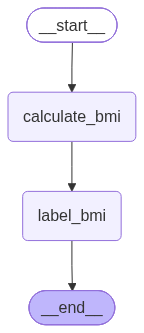

In [25]:
graph=StateGraph(BMIState)

#add nodes
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_bmi',label_bmi)
#add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi',END)

#compile
workflow=graph.compile()
workflow

In [31]:
initial_state={
    'weight':80,
    'height':1.78
}
final_state=workflow.invoke(initial_state)
final_state

80
1.78
25.24933720489837


{'weight': 80, 'height': 1.78, 'bmi': 25.25, 'category': 'Overweight'}

#Simple Sequential Workflow with LLM

In [32]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [34]:
from langchain_groq import ChatGroq

model=ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=GROQ_API_KEY
)

In [35]:
class StateLLM(TypedDict):
  qn:str
  ans:str

In [36]:
def qa(state : StateLLM):
  question=state['qn']
  answer=model.invoke(question).content
  state['ans']=answer
  return state

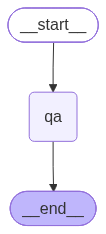

In [38]:
graph=StateGraph(StateLLM)

#add node
graph.add_node('qa',qa)
# add edge
graph.add_edge(START,'qa')
graph.add_edge('qa',END)

workflow=graph.compile()
workflow

In [40]:
initial_state={
    'qn':'What is SUPER AI?'
}
final_state=workflow.invoke(initial_state)
final_state

{'qn': 'What is SUPER AI?',
 'ans': '**SUPER AI** is not a single product or company name that’s widely recognized in the tech world; rather, it’s a shorthand that people (especially in speculative or future‑tech conversations) use to refer to **AI systems that are *super‑intelligent*—i.e., that possess cognitive abilities far beyond those of any human being.**  \n\nBelow is a quick‑look guide to what people mean when they talk about “SUPER AI,” why it matters, and what the debate looks like today.\n\n---\n\n## 1. The Core Idea: Super‑Intelligence\n\n| Term | What It Means | Key Features |\n|------|---------------|--------------|\n| **Artificial General Intelligence (AGI)** | An AI that can understand, learn, and apply knowledge across a wide range of tasks, just like a human. | Flexibility, transfer learning, common sense reasoning. |\n| **Super‑Intelligence** | An AGI that is *significantly* better than the best human brains in virtually every cognitive domain (creativity, problem‑so

In [42]:
print(final_state['ans'])

**SUPER AI** is not a single product or company name that’s widely recognized in the tech world; rather, it’s a shorthand that people (especially in speculative or future‑tech conversations) use to refer to **AI systems that are *super‑intelligent*—i.e., that possess cognitive abilities far beyond those of any human being.**  

Below is a quick‑look guide to what people mean when they talk about “SUPER AI,” why it matters, and what the debate looks like today.

---

## 1. The Core Idea: Super‑Intelligence

| Term | What It Means | Key Features |
|------|---------------|--------------|
| **Artificial General Intelligence (AGI)** | An AI that can understand, learn, and apply knowledge across a wide range of tasks, just like a human. | Flexibility, transfer learning, common sense reasoning. |
| **Super‑Intelligence** | An AGI that is *significantly* better than the best human brains in virtually every cognitive domain (creativity, problem‑solving, emotional insight, etc.). | Rapid self‑im